In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./dataset/mock_time_series_property_data.csv')

In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
property_id = 'property_1'  
property_data = df[df['property_id'] == property_id]  

In [5]:
property_data.tail()

,property_id,date,price
115,property_1,2024-05-31,377800
116,property_1,2024-06-30,377300
117,property_1,2024-07-31,372000
118,property_1,2024-08-31,367500
119,property_1,2024-09-30,377000


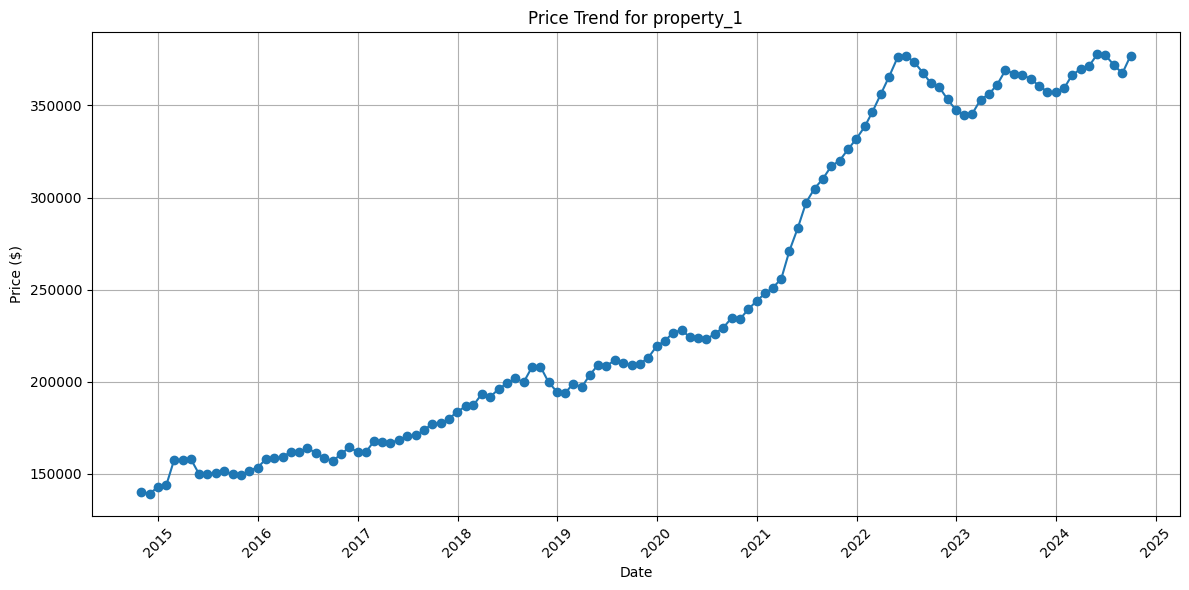

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(property_data['date'], property_data['price'], marker='o')
plt.title(f'Price Trend for {property_id}')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid()
plt.xticks(rotation=45)  
plt.tight_layout()  
plt.show()

In [7]:
property_data = property_data.rename(columns={'date': 'ds', 'price': 'y'})

In [8]:
from prophet import Prophet

model = Prophet(yearly_seasonality=False, changepoint_prior_scale=0.1, seasonality_prior_scale=10.0 )
model.add_seasonality(name='yearly', period=365.25, fourier_order=10)  
model.add_seasonality(name='quarterly', period=91.25, fourier_order=5)

# model = Prophet(
#     yearly_seasonality=True,  
#     weekly_seasonality=True,
#     daily_seasonality=False,
# )

In [9]:
model.fit(property_data)

16:47:12 - cmdstanpy - INFO - Chain [1] start processing


16:47:12 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(periods=11, freq='ME')

In [11]:
forecast = model.predict(future)

In [12]:
historical_forecast = forecast[forecast['ds'] < '2024-09-30']
future_forecast = forecast[forecast['ds'] >= '2024-09-30']

<Figure size 1200x600 with 0 Axes>

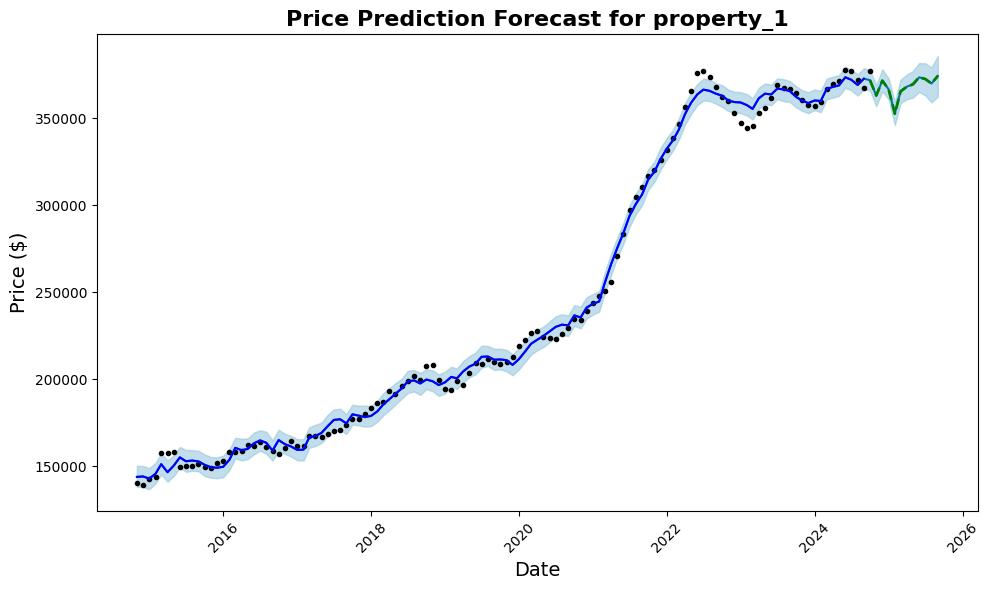

In [13]:
plt.figure(figsize=(12, 6))
model.plot(forecast)

plt.plot(historical_forecast['ds'], historical_forecast['yhat'], label='Historical Prices', color='blue')

plt.plot(future_forecast['ds'], future_forecast['yhat'], label='Predicted Prices', color='green', linestyle='--', linewidth=2)

plt.title(f'Price Prediction Forecast for {property_id}', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.xticks(rotation=45)  
plt.grid()

plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='lightblue', alpha=0.3)

plt.tight_layout()  
plt.show()

In [14]:
predicted_prices = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)
predicted_prices.columns = ['Date', 'Predicted Price', 'Estimated Low Range', 'Estimated High Range']

print(predicted_prices.to_string(index=False))

      Date  Predicted Price  Estimated Low Range  Estimated High Range
2024-09-30    371892.782229        365948.396333         377615.067970
2024-10-31    363039.265279        356951.548852         368901.079844
2024-11-30    371626.106180        365542.452786         378097.559928
2024-12-31    366653.384530        360847.999461         372914.059403
2025-01-31    352632.037883        346169.052434         359346.428594
2025-02-28    365462.508088        358672.678995         372175.137909
2025-03-31    368119.867420        360903.566679         375034.442373
2025-04-30    369494.805296        361909.991876         377154.617530
2025-05-31    373499.337364        365176.738300         381679.625763
2025-06-30    372570.529243        363173.972611         381581.815115
2025-07-31    369970.754831        359117.417469         379148.167368
2025-08-31    374317.727409        362525.343263         385777.540269


In [15]:
predicted_prices.to_csv('./predicted_dataset/predicted_prices.csv', index=False)